In [61]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import faiss
import numpy as np


In [62]:
# load datasets
eval_set = pd.read_csv("../eval/eval_set.csv")
kb = pd.read_csv("kb.csv")
df = pd.read_csv(
    "hf://datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset/"
    "Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv"
)

In [63]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2)
)

kb_tfidf = vectorizer.fit_transform(
    kb["article_text"]
)

print("KB articles:", len(kb))
print("TF-IDF matrix:", kb_tfidf.shape)

KB articles: 27
TF-IDF matrix: (27, 8344)


In [64]:
def search_tfidf(query, top_k=5):

    query_vector = vectorizer.transform([query])

    scores = cosine_similarity(
        query_vector,
        kb_tfidf
    ).flatten()

    top_indices = scores.argsort()[::-1][:top_k]

    results = kb.iloc[top_indices][
        ["article_id", "intent", "category"]
    ].copy()

    results["score"] = scores[top_indices]

    return results.reset_index(drop=True)

In [65]:
def evaluate_tfidf(eval_set, top_k=5):

    results = []

    for _, row in eval_set.iterrows():

        retrieved = search_tfidf(
            row["instruction"],
            top_k=top_k
        )

        predicted_intents = retrieved["intent"].tolist()

        results.append({
            "query_id": row["query_id"],
            "expected_intent": row["intent"],
            "top_intent": predicted_intents[0],
            "top_k_intents": predicted_intents,
            "correct_at_1": row["intent"] == predicted_intents[0],
            "correct_at_5": row["intent"] in predicted_intents
        })

    return pd.DataFrame(results)

In [67]:
tfidf_results = evaluate_tfidf(
    eval_set,
    top_k=5
)

tfidf_results.head()

,query_id,expected_intent,top_intent,top_k_intents,correct_at_1,correct_at_5
0,Q01,cancel_order,change_order,"[change_order, track_order, cancel_order, deli...",False,True
1,Q02,change_order,track_order,"[track_order, cancel_order, change_order, deli...",False,True
2,Q03,change_shipping_address,change_shipping_address,"[change_shipping_address, set_up_shipping_addr...",True,True
3,Q04,check_cancellation_fee,check_cancellation_fee,"[check_cancellation_fee, track_order, track_re...",True,True
4,Q05,check_invoice,track_order,"[track_order, check_invoice, check_payment_met...",False,True


In [68]:
top1_accuracy = tfidf_results["correct_at_1"].mean()
top5_recall = tfidf_results["correct_at_5"].mean()

print(f"TF-IDF Top-1 Accuracy: {top1_accuracy:.3f}")
print(f"TF-IDF Recall@5:       {top5_recall:.3f}")

TF-IDF Top-1 Accuracy: 0.700
TF-IDF Recall@5:       1.000


In [69]:
all_queries_tfidf = vectorizer.transform(
    df["instruction"]
)

similarities = cosine_similarity(
    all_queries_tfidf,
    kb_tfidf
)
top_indices = similarities.argmax(axis=1)

predicted_intents = kb.iloc[
    top_indices
]["intent"].values

TF-IDF Accuracy


In [70]:
accuracy_ifidf = (
    predicted_intents == df["intent"].values
).mean()

print(f"TF-IDF Top-1 Accuracy: {accuracy_ifidf:.4f}")

TF-IDF Top-1 Accuracy: 0.6997


In [71]:
# Get top 5 articles for each ticket
top5 = similarities.argsort(axis=1)[:, -5:]

# Check if the correct intent is in the top 5
correct = 0

for i in range(len(df)):
    predicted_intents = kb.iloc[top5[i]]["intent"].values
    
    if df.iloc[i]["intent"] in predicted_intents:
        correct += 1

recall_at_5_tfidf = correct / len(df)

print(f"TF-IDF Recall@5: {recall_at_5_tfidf:.4f}")

TF-IDF Recall@5: 0.9672


Sentence transformer


In [72]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [73]:
kb_embeddings = model.encode(
    kb["article_text"].tolist(),
    show_progress_bar=True
)

print(kb_embeddings.shape)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

(27, 384)


In [74]:
ticket_embeddings = model.encode(
    df["instruction"].tolist(),
    show_progress_bar=True
)

print(ticket_embeddings.shape)

Batches:   0%|          | 0/840 [00:00<?, ?it/s]

(26872, 384)


Embedding accuracy


In [75]:
embedding_similarities = cosine_similarity(
    ticket_embeddings,
    kb_embeddings
)

print(embedding_similarities.shape)
top_indices = embedding_similarities.argmax(axis=1)

predicted_intents = kb.iloc[
    top_indices
]["intent"].values

accuracy_embedding = (
    predicted_intents == df["intent"].values
).mean()

print(f"Embedding Top-1 Accuracy: {accuracy_embedding:.4f}")

(26872, 27)
Embedding Top-1 Accuracy: 0.8078


In [76]:
top5 = embedding_similarities.argsort(axis=1)[:, -5:]

correct = 0

for i in range(len(df)):
    predicted_intents = kb.iloc[top5[i]]["intent"].values
    
    if df.iloc[i]["intent"] in predicted_intents:
        correct += 1

recall_at_5 = correct / len(df)

print(f"Embedding Recall@5: {recall_at_5:.4f}")

Embedding Recall@5: 0.9903


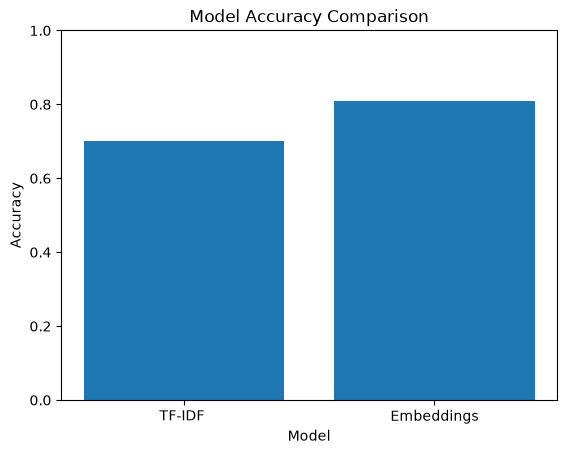

In [77]:
models = ["TF-IDF ", "Embeddings"]
accuracy = [accuracy_ifidf, accuracy_embedding]

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)  # Accuracy ranges from 0 to 1
plt.show()

In [78]:
results = pd.DataFrame({
    "model": ["TF-IDF", "Sentence Transformer"],
    "accuracy": [accuracy_ifidf, accuracy_embedding],
    "recall": [recall_at_5_tfidf, recall_at_5]
})

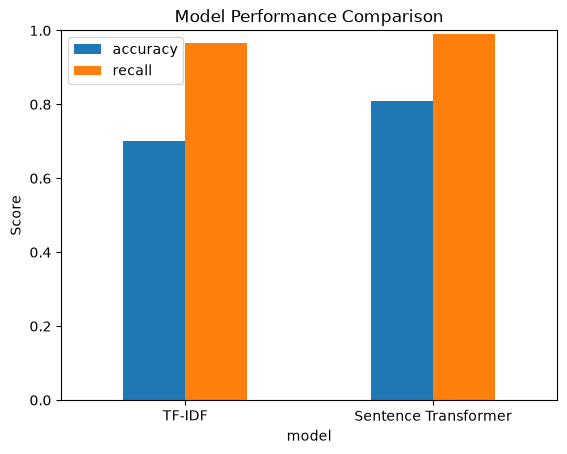

In [79]:
results.set_index("model").plot(kind="bar")

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

In [80]:
# Convert embeddings to float32
kb_vectors = np.array(kb_embeddings).astype("float32")

# Normalize vectors for cosine similarity
faiss.normalize_L2(kb_vectors)

# Create FAISS index
index = faiss.IndexFlatIP(kb_vectors.shape[1])

# Add KB vectors
index.add(kb_vectors)

print("KB vectors:", index.ntotal)

KB vectors: 27


In [81]:
def search_embeddings(query, top_k=5):
    query_vector = model.encode([query]).astype("float32")
    
    faiss.normalize_L2(query_vector)
    
    scores, indices = index.search(query_vector, top_k)

    results = kb.iloc[indices[0]][
        ["article_id", "intent", "category"]
    ].copy()

    results["score"] = scores[0]

    return results.reset_index(drop=True)

In [82]:
# Encode all tickets
ticket_vectors = model.encode(
    df["instruction"].tolist(),
    show_progress_bar=True
).astype("float32")

# Normalize
faiss.normalize_L2(ticket_vectors)

# Search top 5
scores, indices = index.search(ticket_vectors, 5)

print(scores.shape)
print(indices.shape)

Batches:   0%|          | 0/840 [00:00<?, ?it/s]

(26872, 5)
(26872, 5)


FAISS Accuracy


In [83]:
correct = 0

for i in range(len(df)):
    predicted_intent = kb.iloc[indices[i][0]]["intent"]

    if predicted_intent == df.iloc[i]["intent"]:
        correct += 1

faiss_accuracy = correct / len(df)

print(f"FAISS Top-1 Accuracy: {faiss_accuracy:.4f}")

FAISS Top-1 Accuracy: 0.8078


In [84]:
correct = 0

for i in range(len(df)):
    predicted_intents = kb.iloc[indices[i]]["intent"].values

    if df.iloc[i]["intent"] in predicted_intents:
        correct += 1

faiss_recall5 = correct / len(df)

print(f"FAISS Recall@5: {faiss_recall5:.4f}")

FAISS Recall@5: 0.9903


In [85]:
results = pd.DataFrame({
    "model": ["TF-IDF", "Sentence Transformer", "FAISS"],
    "accuracy": [accuracy_ifidf, accuracy_embedding, faiss_accuracy],
    "recall": [recall_at_5_tfidf, recall_at_5, faiss_recall5]
})

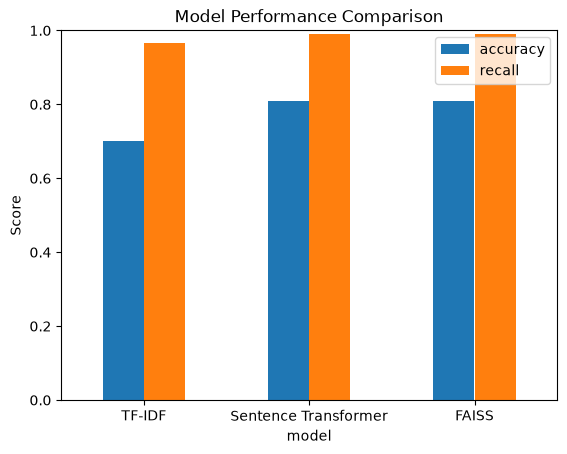

In [86]:
results.set_index("model").plot(kind="bar")

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

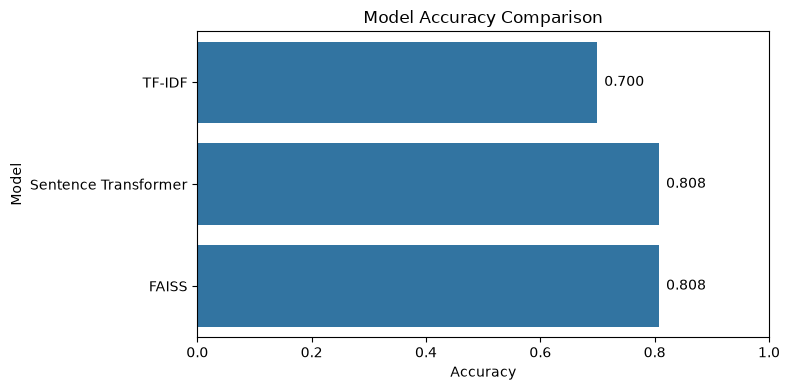

In [87]:
accuracy_results = results.sort_values("accuracy", ascending=True)

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=accuracy_results,
    x="accuracy",
    y="model"
)

# Add accuracy values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=5
    )

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

In [88]:
from sklearn.preprocessing import MinMaxScaler

tfidf_scores = similarities
embedding_scores = embedding_similarities

scaler = MinMaxScaler()

tfidf_norm = scaler.fit_transform(tfidf_scores)
embedding_norm = scaler.fit_transform(embedding_scores)

alpha = 0.5

hybrid_scores = (
    alpha * embedding_norm +
    (1 - alpha) * tfidf_norm
)

Hybrid model accuracy


In [89]:
top_indices = hybrid_scores.argmax(axis=1)

hybrid_pred = kb.iloc[
    top_indices
]["intent"].values

hybrid_accuracy = (
    hybrid_pred == df["intent"].values
).mean()

print(f"Hybrid Top-1 Accuracy: {hybrid_accuracy:.4f}")

Hybrid Top-1 Accuracy: 0.8534


In [90]:
top5 = hybrid_scores.argsort(axis=1)[:, -5:]

correct = 0

for i in range(len(df)):
    predicted_intents = kb.iloc[top5[i]]["intent"].values

    if df.iloc[i]["intent"] in predicted_intents:
        correct += 1

hybrid_recall5 = correct / len(df)

print(f"Hybrid Recall@5: {hybrid_recall5:.4f}")

Hybrid Recall@5: 0.9987


Alpha hyper-parameter tunning


In [91]:
import numpy as np

alphas = np.arange(0, 1.1, 0.1)

results_alpha = []

for alpha in alphas:

    hybrid_scores = (
        alpha * embedding_norm +
        (1 - alpha) * tfidf_norm
    )

    top_indices = hybrid_scores.argmax(axis=1)

    predictions = kb.iloc[
        top_indices
    ]["intent"].values

    accuracy = (
        predictions == df["intent"].values
    ).mean()

    top5 = hybrid_scores.argsort(axis=1)[:, -5:]

    correct = 0

    for i in range(len(df)):
        predicted_intents = kb.iloc[
            top5[i]
        ]["intent"].values

        if df.iloc[i]["intent"] in predicted_intents:
            correct += 1

    recall5 = correct / len(df)

    results_alpha.append([
        alpha,
        accuracy,
        recall5
    ])

alpha_results = pd.DataFrame(
    results_alpha,
    columns=["alpha", "top1_accuracy", "recall_at_5"]
)

alpha_results

,alpha,top1_accuracy,recall_at_5
0,0.0,0.743562,0.970304
1,0.1,0.777910,0.987906
2,0.2,0.804071,0.994381
3,0.3,0.824911,0.997246
4,0.4,0.841322,0.998511
5,0.5,0.853379,0.998698
6,0.6,0.861417,0.998698
7,0.7,0.862496,0.998288
8,0.8,0.854570,0.997283
9,0.9,0.840764,0.994492


In [92]:
alpha_results.sort_values(
    "top1_accuracy",
    ascending=False
)

,alpha,top1_accuracy,recall_at_5
7,0.7,0.862496,0.998288
6,0.6,0.861417,0.998698
8,0.8,0.854570,0.997283
5,0.5,0.853379,0.998698
4,0.4,0.841322,0.998511
9,0.9,0.840764,0.994492
3,0.3,0.824911,0.997246
10,1.0,0.823013,0.987236
2,0.2,0.804071,0.994381
1,0.1,0.777910,0.987906


<Axes: xlabel='alpha', ylabel='top1_accuracy'>

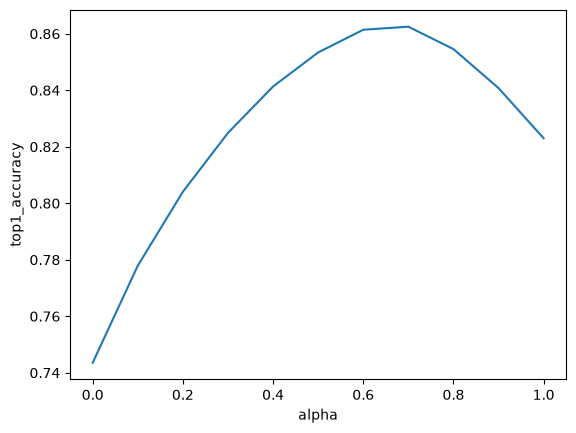

In [93]:
sns.lineplot(alpha_results, x="alpha", y="top1_accuracy")

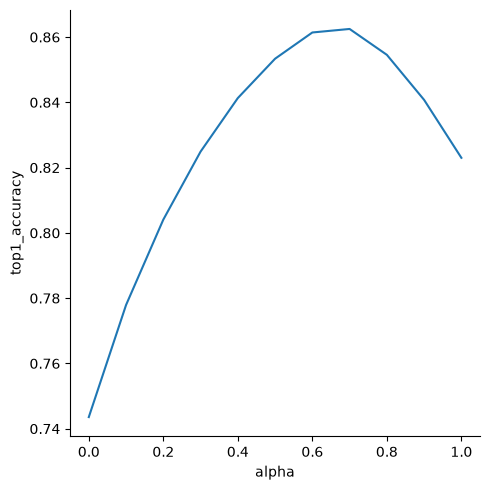

In [94]:
sns.relplot(x="alpha", y="top1_accuracy", data=alpha_results, kind="line")

In [95]:
results = pd.DataFrame({
    "model": ["TF-IDF", "Sentence Transformer", "FAISS", "Hybrid"],
    "accuracy": [accuracy_ifidf, accuracy_embedding, faiss_accuracy, 0.862496],
    "recall": [recall_at_5_tfidf, recall_at_5, faiss_recall5, 0.998288]
})

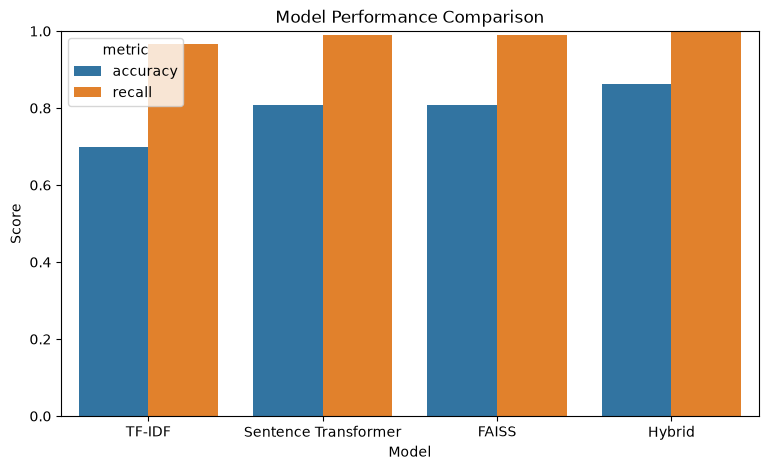

In [96]:
plot_data = results.melt(
    id_vars="model",
    value_vars=["accuracy", "recall"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=plot_data,
    x="model",
    y="score",
    hue="metric"
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.show()

In [97]:
from sklearn.model_selection import train_test_split

indices_all = np.arange(len(df))

tune_idx, test_idx = train_test_split(
    indices_all,
    test_size=0.20,
    random_state=42,
    stratify=df["intent"]
)

print("Tune set:", len(tune_idx))
print("Test set:", len(test_idx))

Tune set: 21497
Test set: 5375


In [98]:
alphas = np.arange(0, 1.1, 0.1)

tune_results = []

for alpha in alphas:

    hybrid_scores = (
        alpha * embedding_norm[tune_idx] +
        (1 - alpha) * tfidf_norm[tune_idx]
    )

    top_indices = hybrid_scores.argmax(axis=1)

    predictions = kb.iloc[
        top_indices
    ]["intent"].values

    actual = df.iloc[tune_idx]["intent"].values

    accuracy = (
        predictions == actual
    ).mean()

    # Recall@5
    top5 = hybrid_scores.argsort(axis=1)[:, -5:]

    correct = 0

    for i in range(len(tune_idx)):
        predicted_intents = kb.iloc[
            top5[i]
        ]["intent"].values

        if actual[i] in predicted_intents:
            correct += 1

    recall5 = correct / len(tune_idx)

    tune_results.append([
        alpha,
        accuracy,
        recall5
    ])

tune_results = pd.DataFrame(
    tune_results,
    columns=["alpha", "top1_accuracy", "recall_at_5"]
)

tune_results.sort_values(
    "top1_accuracy",
    ascending=False
)

,alpha,top1_accuracy,recall_at_5
7,0.7,0.862213,0.998372
6,0.6,0.861516,0.998791
8,0.8,0.854398,0.997395
5,0.5,0.853933,0.998837
4,0.4,0.841373,0.998604
9,0.9,0.840862,0.994697
3,0.3,0.824534,0.997255
10,1.0,0.823185,0.987487
2,0.2,0.803740,0.994557
1,0.1,0.777736,0.988138


In [99]:
best_alpha = tune_results.loc[
    tune_results["top1_accuracy"].idxmax(),
    "alpha"
]

print("Best alpha:", best_alpha)

Best alpha: 0.7000000000000001


In [100]:
test_scores = (
    best_alpha * embedding_norm[test_idx] +
    (1 - best_alpha) * tfidf_norm[test_idx]
)

top_indices = test_scores.argmax(axis=1)

test_predictions = kb.iloc[
    top_indices
]["intent"].values

test_actual = df.iloc[
    test_idx
]["intent"].values

test_accuracy = (
    test_predictions == test_actual
).mean()

print(f"Test Top-1 Accuracy: {test_accuracy:.4f}")

Test Top-1 Accuracy: 0.8636


In [101]:
top5 = test_scores.argsort(axis=1)[:, -5:]

correct = 0

for i in range(len(test_idx)):
    predicted_intents = kb.iloc[
        top5[i]
    ]["intent"].values

    if test_actual[i] in predicted_intents:
        correct += 1

test_recall5 = correct / len(test_idx)

print(f"Test Recall@5: {test_recall5:.4f}")

Test Recall@5: 0.9980
